In [7]:
!pip install scipy numpy pandas emot nltk wordsegment optuna pymorphy3 umap-learn pymorphy3-dicts-ru tqdm xgboost catboost scikit-learn matplotlib seaborn progressbar2

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from matplotlib import animation
import seaborn as sns
from progressbar import progressbar
from tqdm import notebook

from sklearn.cluster import *
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, adjusted_rand_score, jaccard_score
from scipy import sparse
import umap.umap_ as umap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LogNorm
from scipy.stats import kde

%matplotlib inline 

In [3]:
# def saveLabels(labels, filename='hw5_result.csv'):
#     test_df = pd.read_csv("sample_submission.csv")
#     test_df["TARGET"] = labels
#     test_df[["ID", "TARGET"]].to_csv(filename, index=False)

def savingfile(labels, filename='hw5_result.csv'):
    submission = pd.DataFrame({
        "ID": np.arange(len(labels)),
        "TARGET": labels
    })
    submission.to_csv(filename, index=False)

In [5]:
def plotVision(metric, df, lbls=None):
    plt.figure(figsize=[16, 8])
    plt.subplot(1, 2, 1)
    plt.scatter(df[:, 0], df[:, 1], alpha=0.27, c=lbls )
    plt.title(metric)
    plt.grid()
    plt.subplot(1, 2, 2)
    sns.kdeplot(x=df[:, 0], y=df[:, 1], fill=True, thresh=0, levels=100, cmap="mako", cbar=False)
    plt.title('Карта плотностей')
    plt.show()

In [7]:
def plotKMeans(df, labels, model):
    plt.figure(figsize=[12, 6])
    plt.subplot(1, 2, 1)
    centroids = model.cluster_centers_
    plt.scatter(df[:, 0], df[:, 1], alpha=0.27, c=labels )
    plt.scatter(centroids[:, 0], centroids[:, 1], linewidths=10, marker ="x", color='black')
    plt.subplot(1, 2, 2)
    sns.kdeplot(x=df[:, 0], y=df[:, 1], fill=True, thresh=0, levels=100, cmap="mako", cbar=False)
    plt.show()

In [114]:
def plotModel(df, labels):
    plt.figure(figsize=[6, 6])
    plt.scatter(df[:, 0], df[:, 1], alpha=0.27, c=labels )
    plt.show()

In [112]:
def count_clusters(labels, exclude_noise=True):
    labels = np.array(labels)
    unique = np.unique(labels)
    if exclude_noise:
        unique = unique[unique != -1]
    return len(unique)

In [11]:
train = sparse.load_npz("train.npz")
X = train
X

<21000x3049 sparse matrix of type '<class 'numpy.float64'>'
	with 11704521 stored elements in Compressed Sparse Row format>

# Modeling

## PCA (SVD)

In [15]:
%%time
svd = TruncatedSVD(n_components=2, random_state=42)
svd_df = svd.fit_transform(X)

CPU times: total: 3.47 s
Wall time: 1.07 s


In [17]:
svd_df

array([[ 2.51641590e+01,  3.97004254e+00],
       [ 1.86894737e+04,  6.42596088e+04],
       [ 1.81665163e+04,  2.23445199e+04],
       ...,
       [ 1.60282244e+04, -3.56718127e+03],
       [ 6.50991410e+00, -2.74312467e+00],
       [ 2.07370915e+04,  6.12096807e+04]])

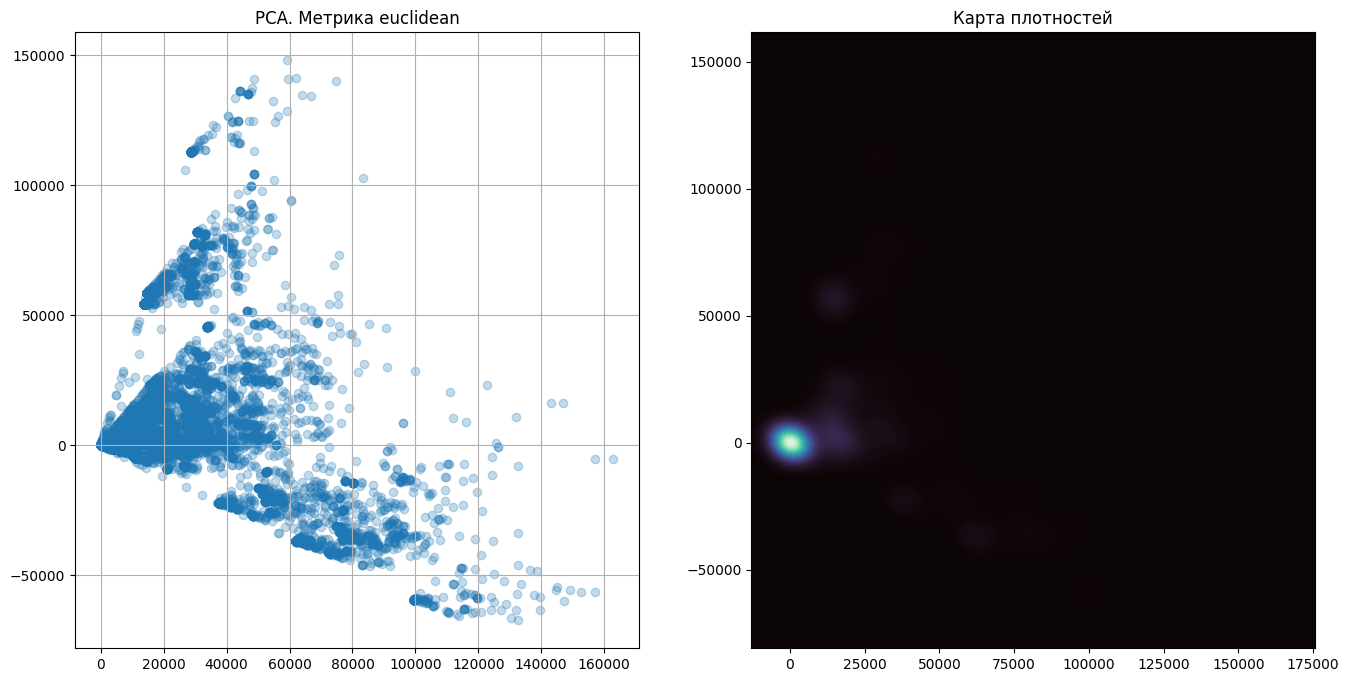

In [19]:
plotVision("PCA. Метрика euclidean", svd_df)

на графиках прослеживаются 6 кластеров 

## t-SNE
(Прождал 20 мин. t-SNE все еще не посчиталось)

In [ ]:
%%time
tsne = TSNE(n_components=2, perplexity=50, metric='euclidean', init='random', verbose=1)
tsne_df = tsne.fit_transform(X)

[t-SNE] Computing 151 nearest neighbors...
[t-SNE] Indexed 21000 samples in 0.049s...


## UMAP

In [23]:
%%time
umapm = umap.UMAP(n_components=3, random_state=42)
umap_df = umapm.fit_transform(X)

C:\Users\User\anaconda3\envs\ml39\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


CPU times: total: 6min 16s
Wall time: 6min 16s


In [25]:
umap_df

array([[-0.5167288,  6.3876977,  8.201505 ],
       [11.041532 , 18.296412 , 13.485625 ],
       [ 9.021954 , -0.9715859,  4.138587 ],
       ...,
       [16.020414 , 10.525464 , 11.385709 ],
       [ 1.9895332,  9.035703 ,  8.710427 ],
       [14.131077 , 12.181305 ,  7.7541656]], dtype=float32)

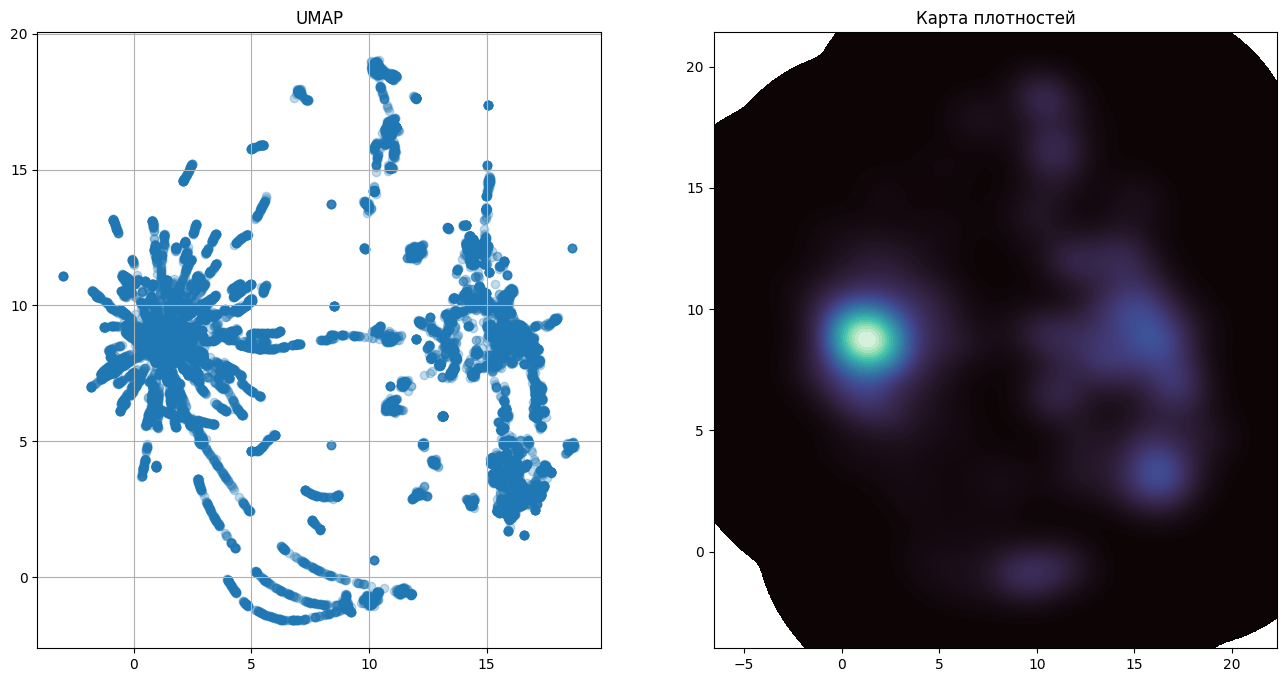

In [34]:
plotVision("UMAP", umap_df)

# K-means
## (для umap)

In [28]:
km = KMeans(n_clusters=6, algorithm='lloyd', init='random', max_iter=500, tol=1e-05, random_state=42)

In [30]:
%%time
km_labels = km.fit_predict(umap_df)
km_labels

C:\Users\User\anaconda3\envs\ml39\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


CPU times: total: 438 ms
Wall time: 642 ms


array([0, 3, 2, ..., 5, 0, 1])

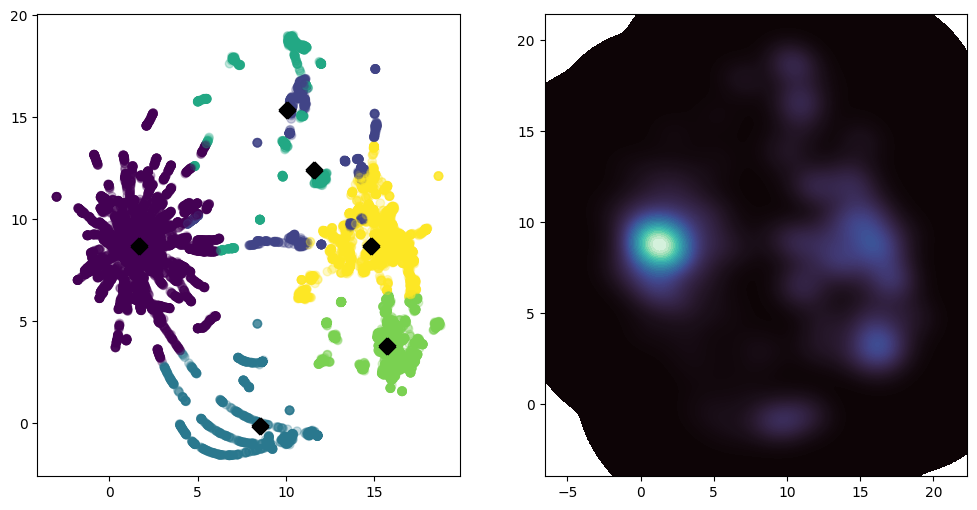

In [32]:
plotKMeans(umap_df, km_labels, km)

C:\Users\User\anaconda3\envs\ml39\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


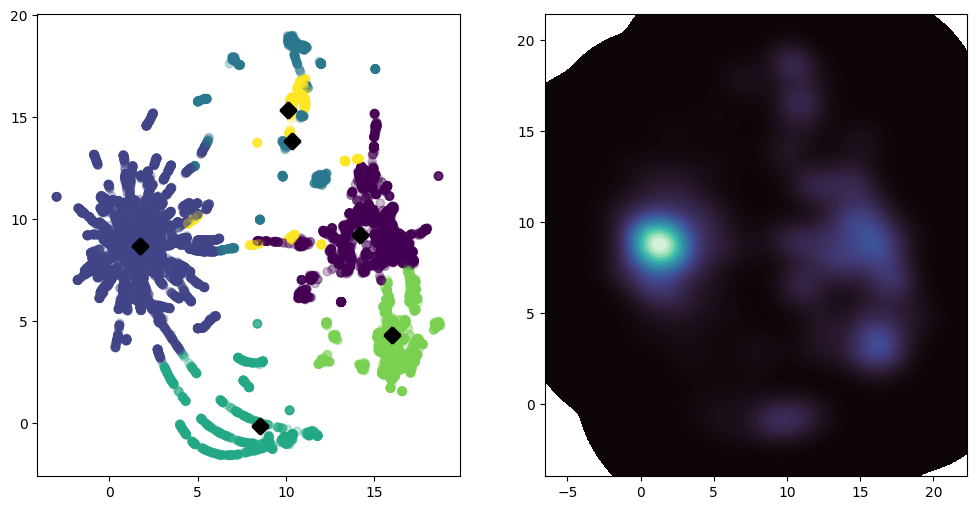

In [430]:
km_param = KMeans(n_clusters=6, algorithm='lloyd', init='k-means++', max_iter=1000, random_state=42).fit(umap_df)
km_param_labels = km_param.predict(umap_df)
plotKMeans(umap_df, km_param_labels, km_param)

In [40]:
# saveLabels(km_param_labels)

In [46]:
savingfile(km_param_labels)

получили score = 0.10711

## для PCA

C:\Users\User\anaconda3\envs\ml39\lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


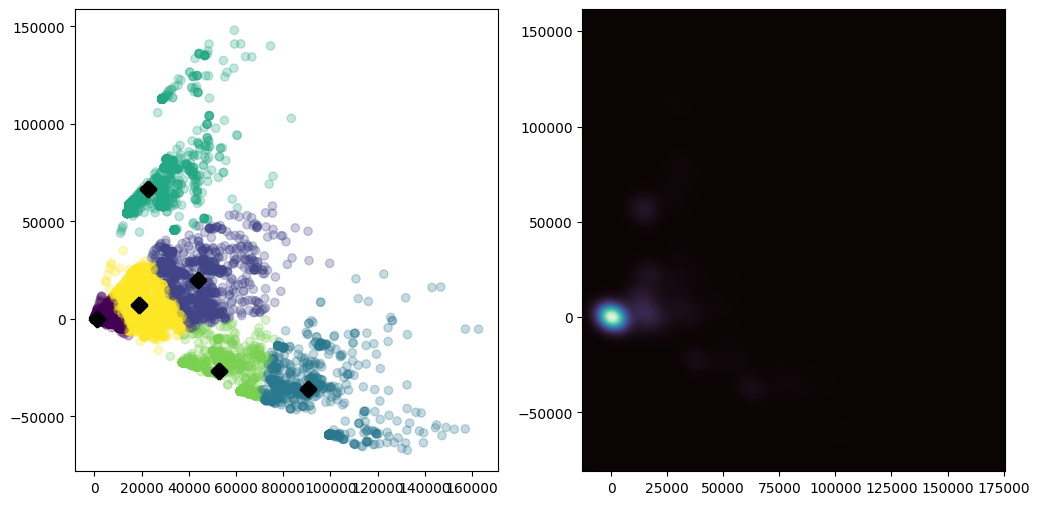

In [48]:
km_param_pca = KMeans(n_clusters=6, algorithm='lloyd', init='k-means++', max_iter=1000, random_state=42).fit(svd_df)
km_param_labels_pca = km_param_pca.predict(svd_df)
plotKMeans(svd_df, km_param_labels_pca, km_param_pca)

# SpectralClustering
(тут мой компьютер завис так, что даже не мог выключиться, пришлось вырубать из розетки)

In [ ]:
scm_param_labels_0 = SpectralClustering(n_components=6, eigen_solver=None, 
                                        gamma=1.0, n_neighbors=8, assign_labels='kmeans', 
                                        random_state=42).fit_predict(umap_df)


# HDBSCAN

In [642]:
hdbscan_model = HDBSCAN(min_cluster_size=290, cluster_selection_epsilon=0.673, min_samples=5).fit(umap_df)

In [644]:
hdbscan_labels = hdbscan_model.labels_

n_clusters = count_clusters(hdbscan_labels)
print(f"Количество кластеров: {n_clusters}")

n_noise = (hdbscan_labels == -1).sum()
print(f"Количество шумовых точек: {n_noise}")

Количество кластеров: 12
Количество шумовых точек: 2884


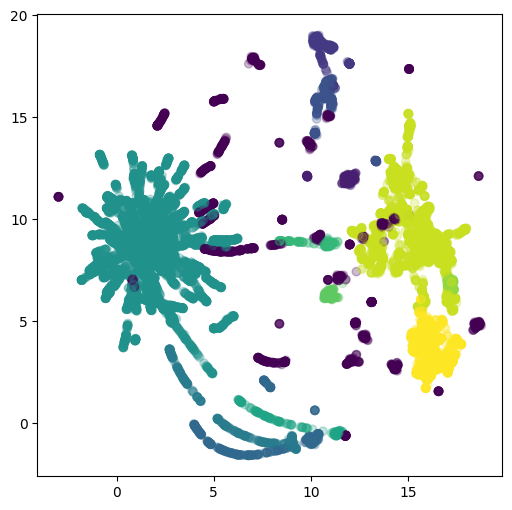

In [646]:
plotModel(umap_df, hdbscan_labels)

In [648]:
savingfile(hdbscan_labels, "hw5_result_hdbscan.csv")

Score: 0.09640